In [1]:
import pandas as pd

# Read the datasets
fake = pd.read_csv("Fake.csv")
real = pd.read_csv("True.csv")

# Show dataset size
print("Fake Dataset:", fake.shape)
print("Real Dataset:", real.shape)

Fake Dataset: (23481, 4)
Real Dataset: (21417, 4)


In [2]:
print(fake.columns)
print(real.columns)

Index(['title', 'text', 'subject', 'date'], dtype='object')
Index(['title', 'text', 'subject', 'date'], dtype='object')


In [3]:
fake.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [4]:
fake.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23481 entries, 0 to 23480
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    23481 non-null  object
 1   text     23481 non-null  object
 2   subject  23481 non-null  object
 3   date     23481 non-null  object
dtypes: object(4)
memory usage: 733.9+ KB


In [5]:
real.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21417 entries, 0 to 21416
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    21417 non-null  object
 1   text     21417 non-null  object
 2   subject  21417 non-null  object
 3   date     21417 non-null  object
dtypes: object(4)
memory usage: 669.4+ KB


In [6]:
print(fake.isnull().sum())
print(real.isnull().sum())

title      0
text       0
subject    0
date       0
dtype: int64
title      0
text       0
subject    0
date       0
dtype: int64


In [7]:
print(fake.duplicated().sum())
print(real.duplicated().sum())

3
206


In [8]:
# Remove duplicate rows

fake = fake.drop_duplicates()

real = real.drop_duplicates()

print("Fake Dataset:", fake.shape)
print("Real Dataset:", real.shape)

Fake Dataset: (23478, 4)
Real Dataset: (21211, 4)


In [9]:
# Add labels
fake["label"] = 0
real["label"] = 1

# Check first 5 rows
fake.head()

,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0


In [10]:
real.head()

,title,text,subject,date,label
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",1
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",1
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",1
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",1
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",1


In [11]:
import pandas as pd

# Merge fake and real datasets
data = pd.concat([fake, real], ignore_index=True)

# Show dataset size
print(data.shape)

# Show first 5 rows
data.head()

(44689, 5)


,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0


In [12]:
# Shuffle the dataset
data = data.sample(frac=1, random_state=42)

# Reset the index
data = data.reset_index(drop=True)

# Show first 5 rows
data.head()

,title,text,subject,date,label
0,WOW! LEFTIST LIBRARIAN REJECTS Shipment Of Chi...,"A school librarian in Cambridge, Massachusetts...",left-news,"Sep 28, 2017",0
1,Kenya opposition leader calls for calm in slum...,NAIROBI (Reuters) - Kenyan opposition leader R...,worldnews,"October 29, 2017",1
2,Egypt rejects U.S. decision to move its embass...,CAIRO (Reuters) - Egypt rejected the U.S. deci...,worldnews,"December 6, 2017",1
3,(AUDIO)NATION OF ISLAM LEADER FARRAKHAN: “WE W...,After a recent speech given by Minister Louis ...,left-news,"May 8, 2015",0
4,Trump Rally Nearly Turns Into A Full-Blown Ra...,Tensions ran high outside of a campaign rally ...,News,"March 11, 2016",0


In [13]:
# Keep only text and label columns
data = data[['text', 'label']]

# Show first 5 rows
data.head()

,text,label
0,"A school librarian in Cambridge, Massachusetts...",0
1,NAIROBI (Reuters) - Kenyan opposition leader R...,1
2,CAIRO (Reuters) - Egypt rejected the U.S. deci...,1
3,After a recent speech given by Minister Louis ...,0
4,Tensions ran high outside of a campaign rally ...,0


In [16]:
import re
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [17]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [18]:
stop_words = set(stopwords.words('english'))

lemmatizer = WordNetLemmatizer()

print("Setup Complete!")

Setup Complete!


In [19]:
def clean_text(text):

    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r'http\S+', '', text)

    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)

    # Remove punctuation and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # Split sentence into words
    words = text.split()

    # Remove stopwords
    words = [word for word in words if word not in stop_words]

    # Lemmatize words
    words = [lemmatizer.lemmatize(word) for word in words]

    return " ".join(words)

In [20]:
# Apply text cleaning function
data["clean_text"] = data["text"].apply(clean_text)

# Show first 5 rows
data.head()

,text,label,clean_text
0,"A school librarian in Cambridge, Massachusetts...",0,school librarian cambridge massachusetts rejec...
1,NAIROBI (Reuters) - Kenyan opposition leader R...,1,nairobi reuters kenyan opposition leader raila...
2,CAIRO (Reuters) - Egypt rejected the U.S. deci...,1,cairo reuters egypt rejected u decision move e...
3,After a recent speech given by Minister Louis ...,0,recent speech given minister louis farrakhan t...
4,Tensions ran high outside of a campaign rally ...,0,tension ran high outside campaign rally donald...


In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [22]:
# Create TF-IDF Vectorizer
tfidf = TfidfVectorizer(max_features=5000)

In [23]:
# Convert text into numerical features
X = tfidf.fit_transform(data["clean_text"])

# Labels
y = data["label"]

print("Feature Matrix Shape:", X.shape)
print("Label Shape:", y.shape)

Feature Matrix Shape: (44689, 5000)
Label Shape: (44689,)


In [24]:
from sklearn.model_selection import train_test_split

In [25]:
# Split data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data :", X_test.shape)

Training Data: (35751, 5000)
Testing Data : (8938, 5000)


In [26]:
 from sklearn.svm import SVC

# Create and train the SVM model
model = SVC(kernel="linear")
model.fit(X_train, y_train)

SVC(kernel='linear')

In [27]:
from sklearn.svm import LinearSVC

# Create and train the SVM model
model = LinearSVC(random_state=42)
model.fit(X_train, y_train)

LinearSVC(random_state=42)

In [28]:
# Predict the labels for the testing dataset
y_pred = model.predict(X_test)

In [29]:
from sklearn.metrics import accuracy_score

# Calculate the accuracy of the SVM model
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9945177892145894


In [31]:
from sklearn.metrics import confusion_matrix

# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[4642   28]
 [  21 4247]]


In [32]:
from sklearn.metrics import classification_report

# Display the classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99      4670
           1       0.99      1.00      0.99      4268

    accuracy                           0.99      8938
   macro avg       0.99      0.99      0.99      8938
weighted avg       0.99      0.99      0.99      8938



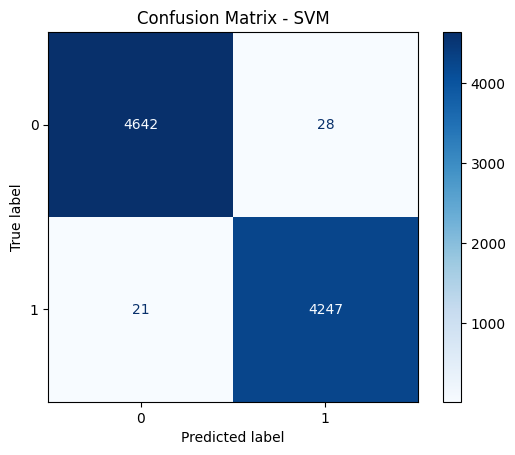

In [33]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Display the confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap="Blues")
plt.title("Confusion Matrix - SVM")
plt.show()